<a href="https://colab.research.google.com/github/soham2710/IIST/blob/main/PageIndex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pymupdf sentence-transformers faiss-cpu rank-bm25 graphviz matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.5 MB/s eta 0:00:00


In [2]:
import os
import fitz
import numpy as np
import faiss
import pandas as pd
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

BASE_PATH = "/content"
PDF_FILES = [f for f in os.listdir(BASE_PATH) if f.endswith(".pdf")]
PDF_FILES.sort()

for f in PDF_FILES:
    doc = fitz.open(os.path.join(BASE_PATH, f))
    print(f"  📄 {f}  ({len(doc)} pages)")

  📄 AcceptableUsePolicy-v2.pdf  (4 pages)
  📄 AssetManagementPolicy-v1.pdf  (6 pages)
  📄 BackupPolicy-v2.pdf  (3 pages)
  📄 BusinessContinuityPlan-v3.pdf  (6 pages)
  📄 ChangeManagementPolicy-v3.pdf  (5 pages)
  📄 CodeofConduct-v2.pdf  (6 pages)
  📄 DataClassificationPolicy-v2.pdf  (6 pages)
  📄 DataProtectionPolicy-v2.pdf  (7 pages)
  📄 DataRetentionPolicy-v2.pdf  (3 pages)


In [3]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

---
# PART 1 — Traditional Chunked RAG

Extract all text → split into fixed-size overlapping chunks → embed → FAISS search.

**Problem:** Chunks break mid-sentence, lose page context, and mix topics.

In [4]:
# ─── Extract full text per document ───
def extract_full_text(pdf_path):
    doc = fitz.open(pdf_path)
    return " ".join(page.get_text() for page in doc if page.get_text().strip())


# ─── Chunk with overlap ───
CHUNK_SIZE = 300
CHUNK_OVERLAP = 50

chunks = []
for f in PDF_FILES:
    text = extract_full_text(os.path.join(BASE_PATH, f))
    for i in range(0, len(text), CHUNK_SIZE - CHUNK_OVERLAP):
        chunk_text = text[i : i + CHUNK_SIZE]
        if len(chunk_text.strip()) > 50:
            chunks.append({"document": f, "text": chunk_text})


# ─── Embed & build FAISS ───
chunk_embeddings = embed_model.encode([c["text"] for c in chunks], show_progress_bar=True)
chunk_embeddings = np.array(chunk_embeddings).astype("float32")
faiss.normalize_L2(chunk_embeddings)

trad_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
trad_index.add(chunk_embeddings)


# ─── Search function ───
def traditional_rag_search(query, top_k=5):
    q_emb = embed_model.encode([query]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, indices = trad_index.search(q_emb, top_k)
    results = []
    for idx, score in zip(indices[0], scores[0]):
        c = chunks[idx]
        results.append({
            "document": c["document"],
            "score": round(float(score), 4),
            "context": c["text"][:200] + "...",
            "method": "Traditional RAG",
        })
    return results


print(f"Total chunks: {len(chunks)}  |  FAISS vectors: {trad_index.ntotal}")

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Total chunks: 360  |  FAISS vectors: 360


---
# PART 2 — PageIndex Hybrid Retrieval

Each **page** is a retrieval unit. Fuses **semantic (FAISS)** + **lexical (BM25)** scores.

**Advantages:** Preserves structure, gives exact page reference, dual scoring catches what either method alone misses.

In [5]:
# ─── Extract per page ───
def extract_pages(pdf_path):
    doc = fitz.open(pdf_path)
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text()
        if text.strip():
            pages.append({
                "document": os.path.basename(pdf_path),
                "page_number": i + 1,
                "text": text,
            })
    return pages


all_pages = []
for f in PDF_FILES:
    all_pages.extend(extract_pages(os.path.join(BASE_PATH, f)))


# ─── FAISS semantic index on full pages ───
page_embeddings = embed_model.encode([p["text"] for p in all_pages], show_progress_bar=True)
page_embeddings = np.array(page_embeddings).astype("float32")
faiss.normalize_L2(page_embeddings)

page_index = faiss.IndexFlatIP(page_embeddings.shape[1])
page_index.add(page_embeddings)


# ─── BM25 lexical index on full pages ───
tokenized_pages = [p["text"].lower().split() for p in all_pages]
bm25 = BM25Okapi(tokenized_pages)


# ─── Hybrid search ───
def pageindex_search(query, top_k=5, alpha=0.7):
    # Semantic
    q_emb = embed_model.encode([query]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, indices = page_index.search(q_emb, top_k * 2)

    # BM25
    bm25_scores = bm25.get_scores(query.lower().split())
    bm25_max = max(bm25_scores) if max(bm25_scores) > 0 else 1.0
    bm25_norm = bm25_scores / bm25_max

    ranked = []
    for idx, sem_score in zip(indices[0], scores[0]):
        p = all_pages[idx]
        final = alpha * float(sem_score) + (1 - alpha) * bm25_norm[idx]
        ranked.append({
            "document": p["document"],
            "page_number": p["page_number"],
            "semantic_score": round(float(sem_score), 4),
            "bm25_score": round(float(bm25_norm[idx]), 4),
            "final_score": round(float(final), 4),
            "context": p["text"][:200] + "...",
            "method": "PageIndex",
        })

    ranked.sort(key=lambda x: x["final_score"], reverse=True)
    return ranked[:top_k]


print(f"Total pages: {len(all_pages)}  |  FAISS vectors: {page_index.ntotal}  |  BM25 docs: {len(tokenized_pages)}")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Total pages: 46  |  FAISS vectors: 46  |  BM25 docs: 46


---
# Run Queries — Both Methods

In [6]:
QUERIES = [
    "Who is responsible for backup and recovery?",
    "What is the process for approving changes to systems?",
    "What is the acceptable use policy for company devices?",
    "How are IT assets tracked and managed?",
    "What does the business continuity plan cover?",
]

trad_results = {}
pi_results = {}

for q in QUERIES:
    trad_results[q] = traditional_rag_search(q, top_k=3)
    pi_results[q] = pageindex_search(q, top_k=3)

In [7]:
# ─── Side-by-side context quality for each query ───
for q in QUERIES:
    t = trad_results[q][0]
    p = pi_results[q][0]

    print(f"\n{'═' * 90}")
    print(f"  QUERY: {q}")
    print(f"{'═' * 90}")
    print(f"\n  ❌ Traditional RAG")
    print(f"     Doc: {t['document']}  |  Score: {t['score']}")
    print(f"     {t['context'][:150]}...")
    print(f"\n  ✅ PageIndex")
    print(f"     Doc: {p['document']}  |  Page {p['page_number']}  |  Hybrid: {p['final_score']}")
    print(f"     Semantic: {p['semantic_score']}  |  BM25: {p['bm25_score']}")
    print(f"     {p['context'][:150]}...")


══════════════════════════════════════════════════════════════════════════════════════════
  QUERY: Who is responsible for backup and recovery?
══════════════════════════════════════════════════════════════════════════════════════════

  ❌ Traditional RAG
     Doc: BackupPolicy-v2.pdf  |  Score: 0.5187
     ry (e.g. US East to US West). By default, data will be backed up daily. The backups are encrypted in the
same way as live production data. Backups are...

  ✅ PageIndex
     Doc: BusinessContinuityPlan-v3.pdf  |  Page 1  |  Hybrid: 0.5917
     Semantic: 0.4167  |  BM25: 1.0
     Business Continuity Plan
Ziplyne Inc.
____________________________________________________________________________
Purpose
This policy establishes pro...

══════════════════════════════════════════════════════════════════════════════════════════
  QUERY: What is the process for approving changes to systems?
══════════════════════════════════════════════════════════════════════════════════════════

  ❌ Tradi

---
# PART 3 — Visual Comparison

In [8]:
import graphviz
from IPython.display import display

TRADITIONAL RAG PIPELINE


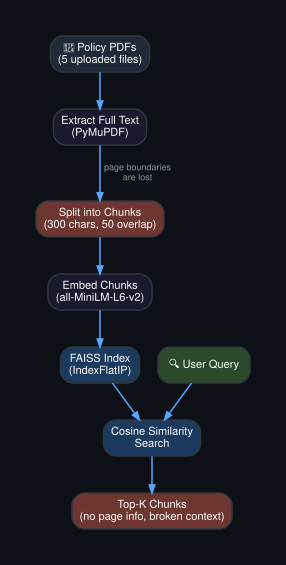

In [9]:
# ─── Traditional RAG Flow ───
g = graphviz.Digraph("Traditional_RAG", format="png")
g.attr(rankdir="TB", bgcolor="#0d1117", pad="0.5")
g.attr("node", shape="box", style="filled,rounded", fontname="Helvetica",
       fontsize="11", fontcolor="white", color="#30363d", penwidth="1.5")
g.attr("edge", color="#58a6ff", penwidth="1.5", arrowsize="0.8",
       fontname="Helvetica", fontsize="9", fontcolor="#8b949e")

g.node("docs", "📄 Policy PDFs\n(5 uploaded files)", fillcolor="#1f2937")
g.node("extract", "Extract Full Text\n(PyMuPDF)", fillcolor="#1a1a2e")
g.node("chunk", "Split into Chunks\n(300 chars, 50 overlap)", fillcolor="#6e3630")
g.node("embed", "Embed Chunks\n(all-MiniLM-L6-v2)", fillcolor="#1a1a2e")
g.node("faiss", "FAISS Index\n(IndexFlatIP)", fillcolor="#1c3a5e")
g.node("query", "🔍 User Query", fillcolor="#2a4a2a")
g.node("search", "Cosine Similarity\nSearch", fillcolor="#1c3a5e")
g.node("result", "Top-K Chunks\n(no page info, broken context)", fillcolor="#6e3630")

g.edge("docs", "extract")
g.edge("extract", "chunk", label="  page boundaries\n  are lost")
g.edge("chunk", "embed")
g.edge("embed", "faiss")
g.edge("query", "search")
g.edge("faiss", "search")
g.edge("search", "result")

print("TRADITIONAL RAG PIPELINE")
display(g)

PAGEINDEX HYBRID RETRIEVAL PIPELINE


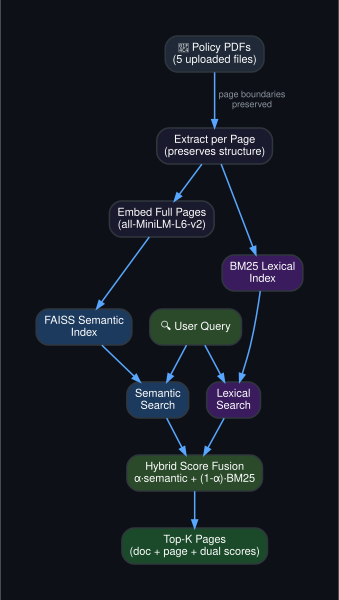

In [10]:
# ─── PageIndex Flow ───
g2 = graphviz.Digraph("PageIndex", format="png")
g2.attr(rankdir="TB", bgcolor="#0d1117", pad="0.5")
g2.attr("node", shape="box", style="filled,rounded", fontname="Helvetica",
        fontsize="11", fontcolor="white", color="#30363d", penwidth="1.5")
g2.attr("edge", color="#58a6ff", penwidth="1.5", arrowsize="0.8",
        fontname="Helvetica", fontsize="9", fontcolor="#8b949e")

g2.node("docs", "📄 Policy PDFs\n(5 uploaded files)", fillcolor="#1f2937")
g2.node("pages", "Extract per Page\n(preserves structure)", fillcolor="#1a1a2e")
g2.node("embed", "Embed Full Pages\n(all-MiniLM-L6-v2)", fillcolor="#1a1a2e")
g2.node("faiss", "FAISS Semantic\nIndex", fillcolor="#1c3a5e")
g2.node("bm25", "BM25 Lexical\nIndex", fillcolor="#3a1c5e")
g2.node("query", "🔍 User Query", fillcolor="#2a4a2a")
g2.node("sem", "Semantic\nSearch", fillcolor="#1c3a5e")
g2.node("lex", "Lexical\nSearch", fillcolor="#3a1c5e")
g2.node("fuse", "Hybrid Score Fusion\nα·semantic + (1-α)·BM25", fillcolor="#2a4a2a")
g2.node("result", "Top-K Pages\n(doc + page + dual scores)", fillcolor="#1a4a2a")

g2.edge("docs", "pages", label="  page boundaries\n  preserved")
g2.edge("pages", "embed")
g2.edge("pages", "bm25")
g2.edge("embed", "faiss")
g2.edge("query", "sem")
g2.edge("query", "lex")
g2.edge("faiss", "sem")
g2.edge("bm25", "lex")
g2.edge("sem", "fuse")
g2.edge("lex", "fuse")
g2.edge("fuse", "result")

print("PAGEINDEX HYBRID RETRIEVAL PIPELINE")
display(g2)

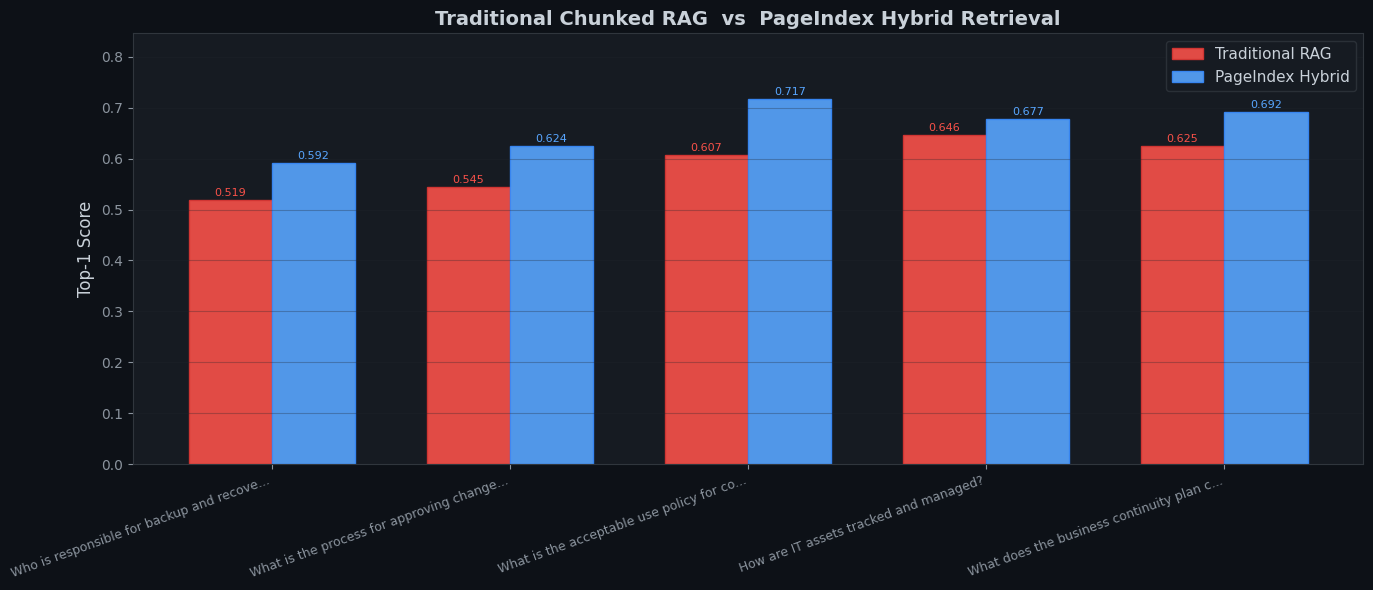

In [11]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
})

labels = [q[:40] + "..." if len(q) > 40 else q for q in QUERIES]
trad_scores = [trad_results[q][0]["score"] for q in QUERIES]
pi_scores = [pi_results[q][0]["final_score"] for q in QUERIES]

x = np.arange(len(QUERIES))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w/2, trad_scores, w, label="Traditional RAG",
            color="#f85149", edgecolor="#da3633", alpha=0.9)
b2 = ax.bar(x + w/2, pi_scores, w, label="PageIndex Hybrid",
            color="#58a6ff", edgecolor="#388bfd", alpha=0.9)

ax.set_ylabel("Top-1 Score", fontsize=12)
ax.set_title("Traditional Chunked RAG  vs  PageIndex Hybrid Retrieval",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.legend(fontsize=11, facecolor="#161b22", edgecolor="#30363d")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(trad_scores), max(pi_scores)) * 1.18)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", fontsize=8, color="#f85149")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", fontsize=8, color="#58a6ff")

plt.tight_layout()
plt.show()

In [12]:
# ─── Summary Table ───
rows = []
for q in QUERIES:
    t = trad_results[q][0]
    p = pi_results[q][0]
    rows.append({
        "Query": q,
        "RAG → Doc": t["document"].replace(".pdf", ""),
        "RAG Score": t["score"],
        "PageIdx → Doc": p["document"].replace(".pdf", ""),
        "Page #": p["page_number"],
        "Semantic": p["semantic_score"],
        "BM25": p["bm25_score"],
        "Hybrid": p["final_score"],
    })

pd.DataFrame(rows).style.background_gradient(
    subset=["RAG Score", "Hybrid"], cmap="Blues"
)

,Query,RAG → Doc,RAG Score,PageIdx → Doc,Page #,Semantic,BM25,Hybrid
0,Who is responsible for backup and recovery?,BackupPolicy-v2,0.518700,BusinessContinuityPlan-v3,1,0.416700,1.000000,0.591700
1,What is the process for approving changes to systems?,ChangeManagementPolicy-v3,0.544900,ChangeManagementPolicy-v3,2,0.497100,0.920100,0.624000
2,What is the acceptable use policy for company devices?,AcceptableUsePolicy-v2,0.606500,AcceptableUsePolicy-v2,1,0.595300,1.000000,0.716700
3,How are IT assets tracked and managed?,AssetManagementPolicy-v1,0.645900,AssetManagementPolicy-v1,2,0.538200,1.000000,0.676700
4,What does the business continuity plan cover?,BusinessContinuityPlan-v3,0.624600,BusinessContinuityPlan-v3,1,0.559700,1.000000,0.691800
